# Importing all libraries and files

In [1]:
import numpy as np
from astropy.io import fits

imname = '/kaggle/input/datasets/abshafi2021/m84-fits/M84.fits'

imhdr = fits.getheader(imname)
imdata = fits.getdata(imname)

X, Y = np.meshgrid(
    np.arange(1, imhdr['NAXIS1'] + 1),
    np.arange(1, imhdr['NAXIS2'] + 1)
)

Xc, Yc = 1000.0, 1000.0

R = np.sqrt((X - Xc)**2 + (Y - Yc)**2)

R = R.flatten()
pixvals = imdata.flatten()

# Raw Iamge

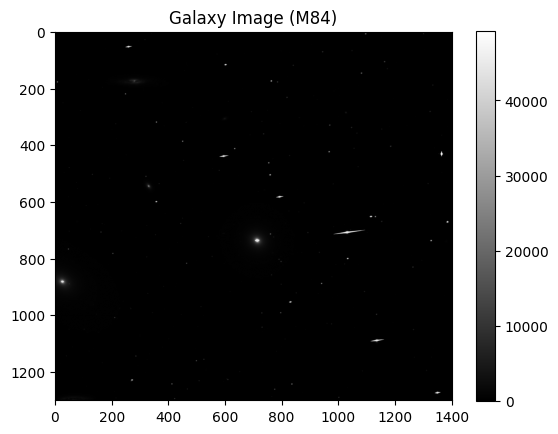

In [2]:
import matplotlib.pyplot as plt

plt.imshow(imdata, cmap='gray')
plt.colorbar()
plt.title("Galaxy Image (M84)")
plt.show()

# Brightness vs Distance

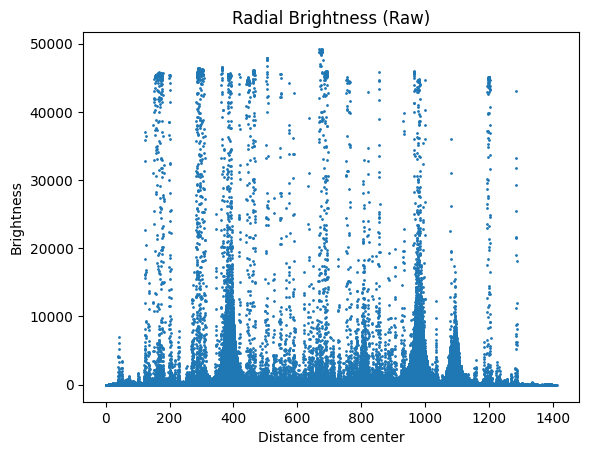

In [3]:
plt.scatter(R, pixvals, s=1)
plt.xlabel("Distance from center")
plt.ylabel("Brightness")
plt.title("Radial Brightness (Raw)")
plt.show()

# Smoothed curve

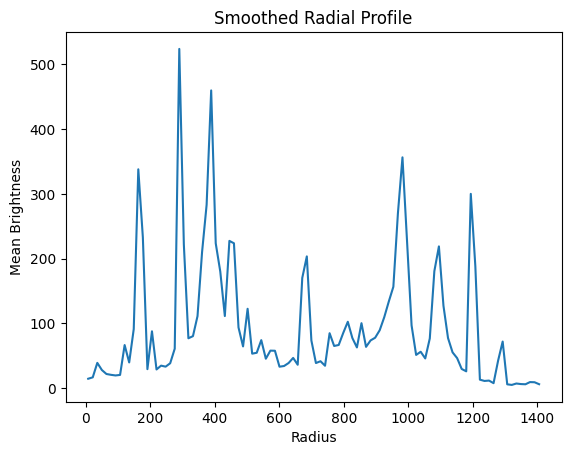

In [4]:
from scipy.stats import binned_statistic

bins = 100

radial_mean, bin_edges, _ = binned_statistic(
    R,
    pixvals,
    statistic='mean',
    bins=bins
)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.plot(bin_centers, radial_mean)
plt.xlabel("Radius")
plt.ylabel("Mean Brightness")
plt.title("Smoothed Radial Profile")
plt.show()

# Heatmap view

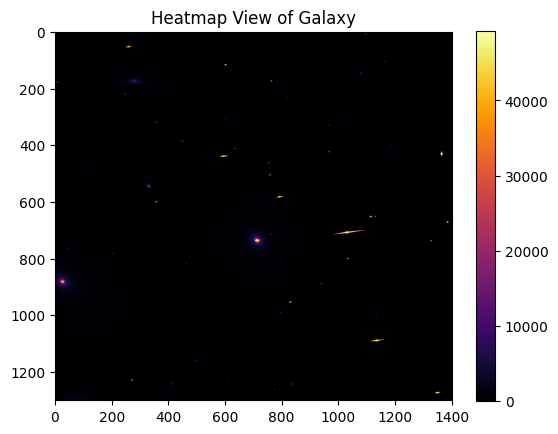

In [5]:
plt.imshow(imdata, cmap='inferno')
plt.colorbar()
plt.title("Heatmap View of Galaxy")
plt.show()

# Histogram

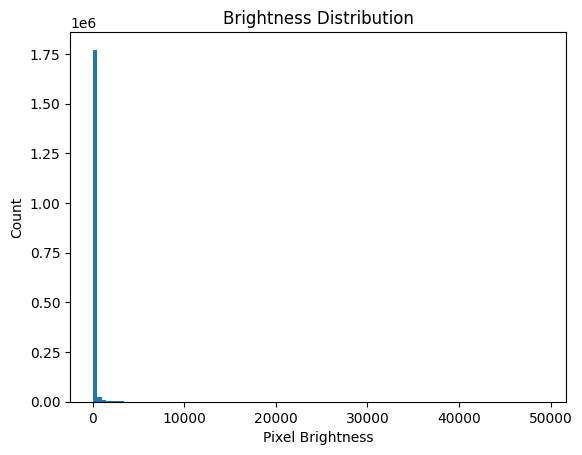

In [6]:
plt.hist(pixvals, bins=100)
plt.xlabel("Pixel Brightness")
plt.ylabel("Count")
plt.title("Brightness Distribution")
plt.show()

# Log Scale View

/tmp/ipykernel_16/3023589636.py:1: RuntimeWarning: invalid value encountered in log1p
  plt.imshow(np.log1p(imdata), cmap='gray')


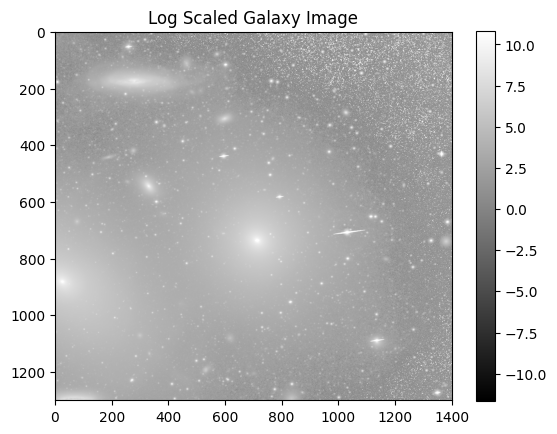

In [7]:
plt.imshow(np.log1p(imdata), cmap='gray')
plt.colorbar()
plt.title("Log Scaled Galaxy Image")
plt.show()

# Marking the center of galaxy

/tmp/ipykernel_16/437224121.py:2: RuntimeWarning: invalid value encountered in log1p
  plt.imshow(np.log1p(imdata), cmap='gray', origin='lower')


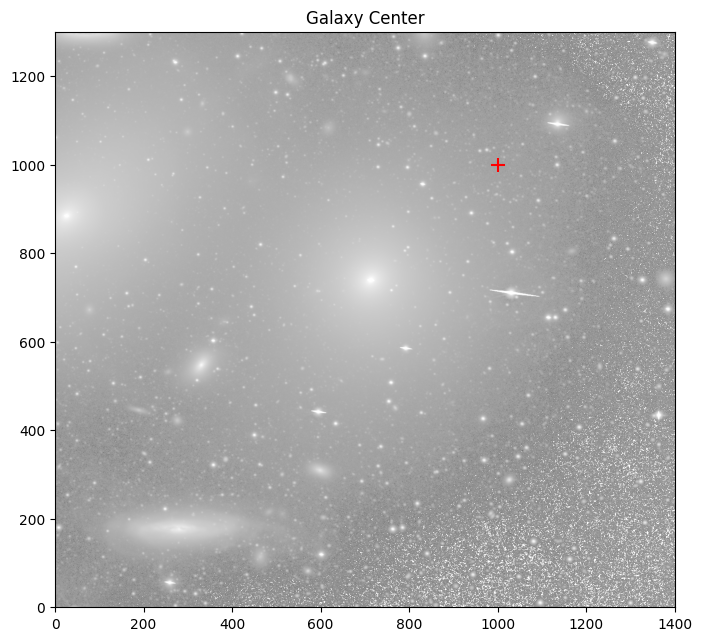

In [8]:
plt.figure(figsize=(8,8))
plt.imshow(np.log1p(imdata), cmap='gray', origin='lower')
plt.scatter(Xc, Yc, color='red', s=100, marker='+')
plt.title("Galaxy Center")
plt.show()

# Zoom into the galaxy core

/tmp/ipykernel_16/638138197.py:3: RuntimeWarning: invalid value encountered in log1p
  np.log1p(imdata),


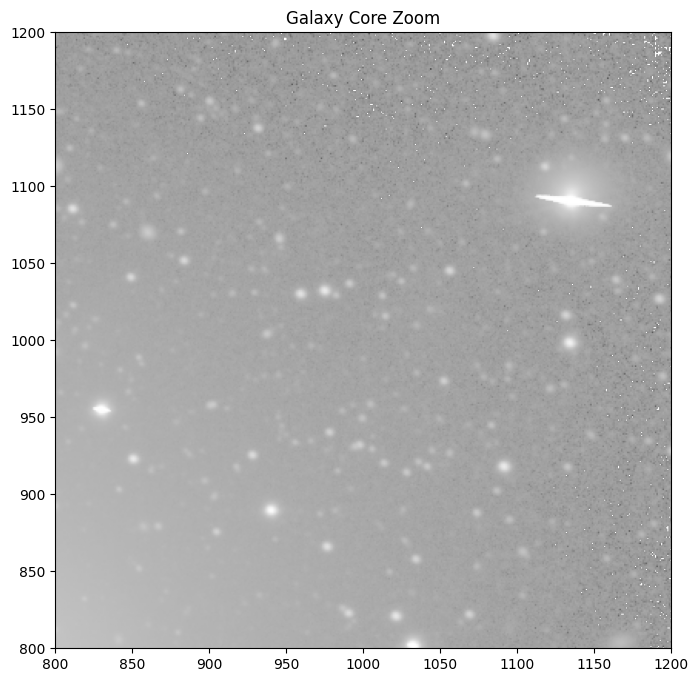

In [9]:
plt.figure(figsize=(8,8))
plt.imshow(
    np.log1p(imdata),
    cmap='gray',
    origin='lower'
)

plt.xlim(Xc-200, Xc+200)
plt.ylim(Yc-200, Yc+200)

plt.title("Galaxy Core Zoom")
plt.show()

# Contour Map

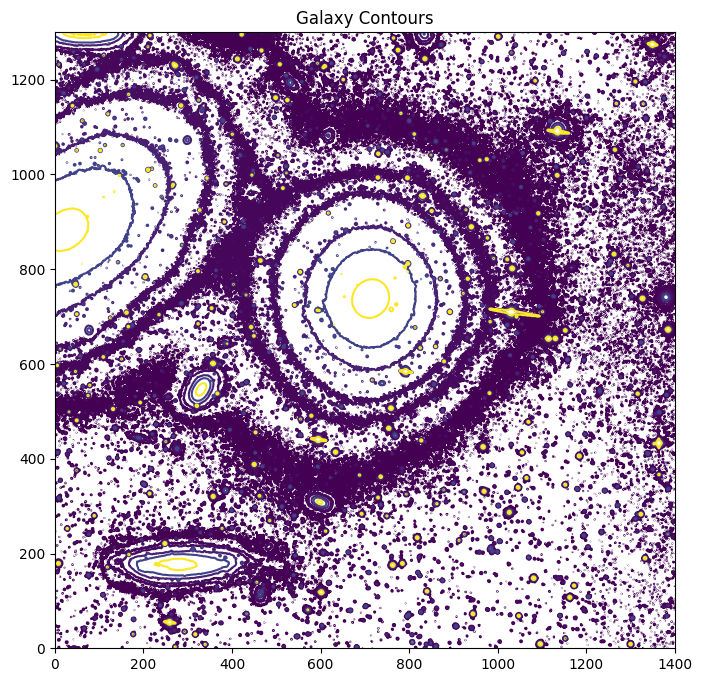

In [10]:
plt.figure(figsize=(8,8))

levels = np.percentile(
    imdata,
    [50,70,80,90,95,99]
)

plt.contour(
    imdata,
    levels=levels
)

plt.title("Galaxy Contours")
plt.show()

# Radius vs Pixel

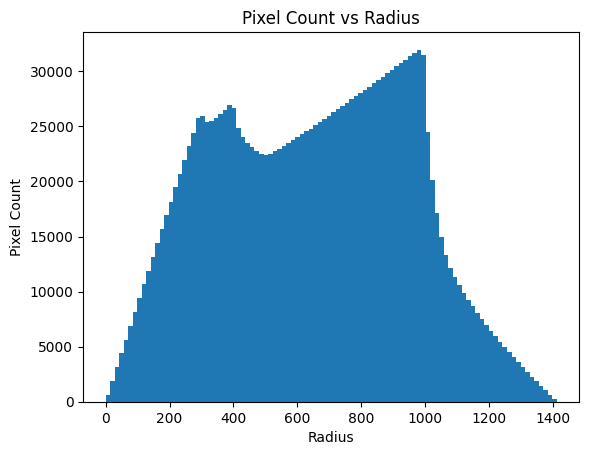

In [11]:
plt.hist(R, bins=100)

plt.xlabel("Radius")
plt.ylabel("Pixel Count")

plt.title("Pixel Count vs Radius")
plt.show()

# 3D Galaxy Surface

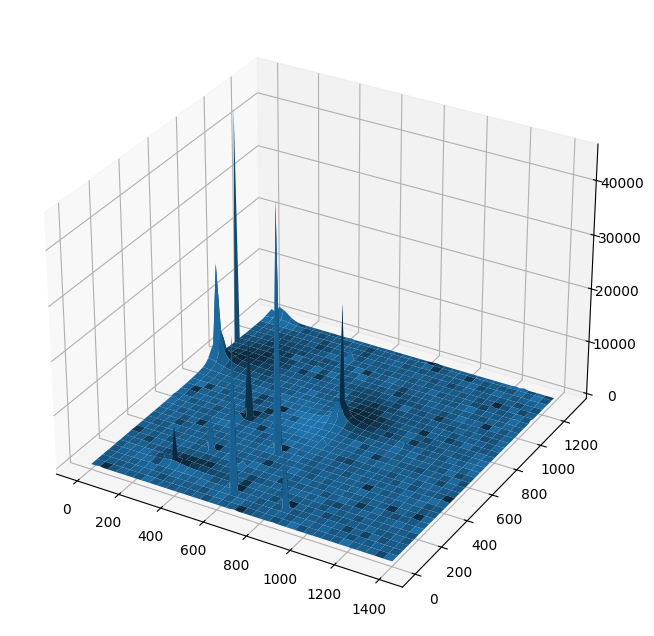

In [12]:
from mpl_toolkits.mplot3d import Axes3D

step = 20

X_small = X[::step, ::step]
Y_small = Y[::step, ::step]
Z_small = imdata[::step, ::step]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X_small,
    Y_small,
    Z_small
)

plt.show()